In [1]:
# ============================================================
# SECTION 0 — CHECK DATASET
# ============================================================

import os

if not os.path.exists("./data/images"):
    raise FileNotFoundError(
        "Dataset not found. Please run Medium notebook first."
    )

print("Dataset ready!")

Dataset ready!


In [2]:
# ============================================================
# SECTION 1 — IMPORTS
# ============================================================

import os
import glob
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.utils as vutils

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import spectral_norm

import matplotlib.pyplot as plt

In [3]:
# ============================================================
# SECTION 2 — CONFIG
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = "/home/wwww/zhj/GAN/data/images"

BATCH_SIZE = 128
IMAGE_SIZE = 64
CHANNELS_IMG = 3
Z_DIM = 128
NUM_EPOCHS = 120
FEATURES_GEN = 64
FEATURES_DISC = 64
LR = 2e-4

SAVE_DIR = "outputs_strong"
os.makedirs(SAVE_DIR, exist_ok=True)

In [4]:
# ============================================================
# SECTION 3 — DATASET
# ============================================================

class AnimeDataset(Dataset):
    def __init__(self, root):
        self.files = glob.glob(os.path.join(root, "*.jpg"))

        self.transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        return self.transform(img)


dataset = AnimeDataset(DATA_DIR)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

In [5]:
# ============================================================
# SECTION 4 — GENERATOR
# ============================================================

class Generator(nn.Module):
    def __init__(self, z_dim, channels_img, features_g):
        super().__init__()

        self.net = nn.Sequential(
            self._block(z_dim, features_g * 8, 4, 1, 0),
            self._block(features_g * 8, features_g * 4, 4, 2, 1),
            self._block(features_g * 4, features_g * 2, 4, 2, 1),
            self._block(features_g * 2, features_g, 4, 2, 1),
            nn.ConvTranspose2d(features_g, channels_img, 4, 2, 1),
            nn.Tanh()
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

In [6]:
# ============================================================
# SECTION 5 — SNGAN DISCRIMINATOR
# ============================================================

class Discriminator(nn.Module):
    def __init__(self, channels_img, features_d):
        super().__init__()

        self.disc = nn.Sequential(
            spectral_norm(nn.Conv2d(channels_img, features_d, 4, 2, 1)),
            nn.LeakyReLU(0.2),

            spectral_norm(nn.Conv2d(features_d, features_d * 2, 4, 2, 1)),
            nn.LeakyReLU(0.2),

            spectral_norm(nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1)),
            nn.LeakyReLU(0.2),

            spectral_norm(nn.Conv2d(features_d * 4, features_d * 8, 4, 2, 1)),
            nn.LeakyReLU(0.2),

            spectral_norm(nn.Conv2d(features_d * 8, 1, 4, 2, 0)),
        )

    def forward(self, x):
        return self.disc(x)

In [7]:
# ============================================================
# SECTION 6 — MODEL INIT
# ============================================================


gen = Generator(Z_DIM, CHANNELS_IMG, FEATURES_GEN).to(DEVICE)
disc = Discriminator(CHANNELS_IMG, FEATURES_DISC).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()

opt_gen = optim.Adam(gen.parameters(), lr=LR, betas=(0.0, 0.9))
opt_disc = optim.Adam(disc.parameters(), lr=LR, betas=(0.0, 0.9))

fixed_noise = torch.randn(64, Z_DIM, 1, 1).to(DEVICE)

In [8]:
# ============================================================
# SECTION 7 — TRAINING
# ============================================================

print("Starting Training SNGAN...")

for epoch in range(NUM_EPOCHS):

    loop = tqdm(loader, leave=True)

    for batch_idx, real in enumerate(loop):
        real = real.to(DEVICE)
        cur_batch_size = real.shape[0]

        noise = torch.randn(cur_batch_size, Z_DIM, 1, 1).to(DEVICE)
        fake = gen(noise)

        disc_real = disc(real).reshape(-1)
        loss_disc_real = criterion(disc_real, torch.ones_like(disc_real))

        disc_fake = disc(fake.detach()).reshape(-1)
        loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))

        loss_disc = (loss_disc_real + loss_disc_fake) / 2

        disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        output = disc(fake).reshape(-1)
        loss_gen = criterion(output, torch.ones_like(output))

        gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        loop.set_description(f"Epoch [{epoch}/{NUM_EPOCHS}]")
        loop.set_postfix(
            loss_disc=loss_disc.item(),
            loss_gen=loss_gen.item()
        )

    with torch.no_grad():
        fake = gen(fixed_noise).detach().cpu()

    grid = vutils.make_grid(fake[:64], normalize=True)

    torchvision.utils.save_image(
        grid,
        os.path.join(SAVE_DIR, f"epoch_{epoch}.png")
    )

Starting Training SNGAN...


Epoch [119/120]: 100%|██████████| 497/497 [00:05<00:00, 93.43it/s, loss_disc=0.622, loss_gen=0.739]


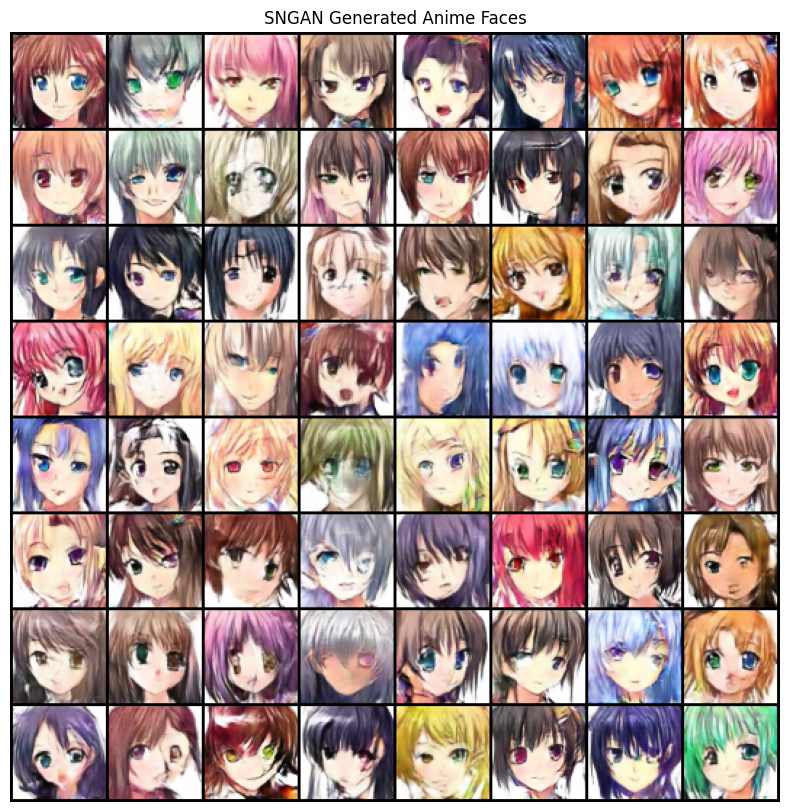

In [9]:
# ============================================================
# SECTION 8 — FINAL IMAGE MATRIX
# ============================================================

plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("SNGAN Generated Anime Faces")
plt.imshow(grid.permute(1, 2, 0))
plt.show()